In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
df = pd.read_csv("../data/raw/archive.zip")

In [3]:
df.shape

(9380, 22)

In [4]:
df.describe()

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


In [5]:
df.describe(include="object")

/tmp/ipykernel_34806/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeResult,HalfTimeResult
count,9380,9380,9380,9380,9380,9380
unique,25,2599,46,46,3,3
top,2000/01,2001-05-19,Everton,Liverpool,H,D
freq,380,10,471,471,4299,3840


# Target Variable Distribution


In [6]:
df["FullTimeResult"].value_counts()

FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64

In [7]:
df["FullTimeResult"].value_counts(normalize=True) * 100

FullTimeResult
H    45.831557
A    29.509595
D    24.658849
Name: proportion, dtype: float64

# 3: Goals Distribution

In [9]:
df["FullTimeHomeGoals"]

0       4
1       4
2       1
3       2
4       2
       ..
9375    4
9376    1
9377    1
9378    3
9379    1
Name: FullTimeHomeGoals, Length: 9380, dtype: int64

In [10]:
df["FullTimeAwayGoals"]

0       0
1       2
2       3
3       2
4       0
       ..
9375    3
9376    1
9377    1
9378    1
9379    1
Name: FullTimeAwayGoals, Length: 9380, dtype: int64

In [12]:
df["TotalGoals"] = (
    df["FullTimeHomeGoals"] +
    df["FullTimeAwayGoals"]
)

# 4: Home Advantage

In [13]:
avg_home_goals = df["FullTimeHomeGoals"].mean()
print(f"Average Home Goals: {avg_home_goals:.2f}")

Average Home Goals: 1.54


In [14]:
avg_away_goals = df["FullTimeAwayGoals"].mean()
print(f"Average Away Goals: {avg_away_goals:.2f}")

Average Away Goals: 1.18


In [15]:
home_win_pct = (df["FullTimeResult"] == "H").mean() * 100
print(f"Home Win %: {home_win_pct:.2f}%")

Home Win %: 45.83%


In [16]:
away_win_pct = (df["FullTimeResult"] == "A").mean() * 100
print(f"Away Win %: {away_win_pct:.2f}%")

Away Win %: 29.51%


In [17]:
draw_pct = (df["FullTimeResult"] == "D").mean() * 100
print(f"Draw %: {draw_pct:.2f}%")

Draw %: 24.66%


In [19]:
home_advantage = pd.DataFrame({
    "Category": ["Home Goals", "Away Goals", "Home Win %", "Away Win %"],
    "Value": [
        avg_home_goals,
        avg_away_goals,
        home_win_pct,
        away_win_pct
    ]
})

home_advantage

,Category,Value
0,Home Goals,1.535394
1,Away Goals,1.182623
2,Home Win %,45.831557
3,Away Win %,29.509595


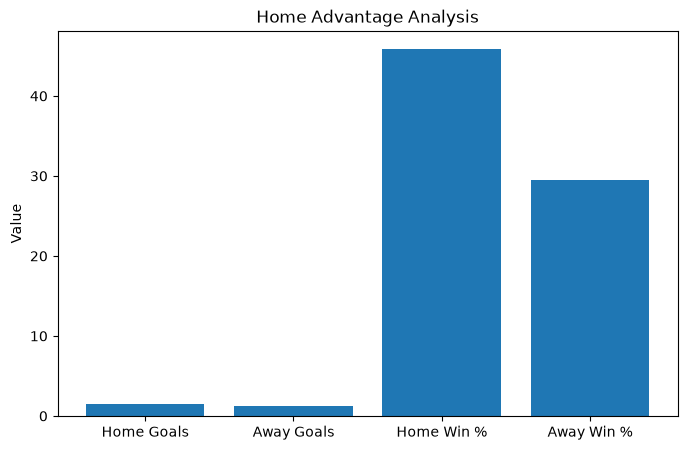

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(home_advantage["Category"], home_advantage["Value"])

plt.title("Home Advantage Analysis")
plt.ylabel("Value")

plt.show()

## Observation

- Home teams score more goals on average than away teams.
- Home teams win a significantly higher percentage of matches.
- This confirms the presence of a home advantage in the Premier League.
- Home advantage may be an important feature for the prediction model.

# 5: Top Winning Teams

In [22]:
home_wins = df[df["FullTimeResult"] == "H"]["HomeTeam"].value_counts()

In [23]:
away_wins = df[df["FullTimeResult"] == "A"]["AwayTeam"].value_counts()

In [24]:
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)

In [25]:
top10 = total_wins.head(10)
top10

HomeTeam
Man United     552
Arsenal        534
Chelsea        533
Liverpool      530
Man City       500
Tottenham      440
Everton        348
Newcastle      315
Aston Villa    279
West Ham       272
Name: count, dtype: int64

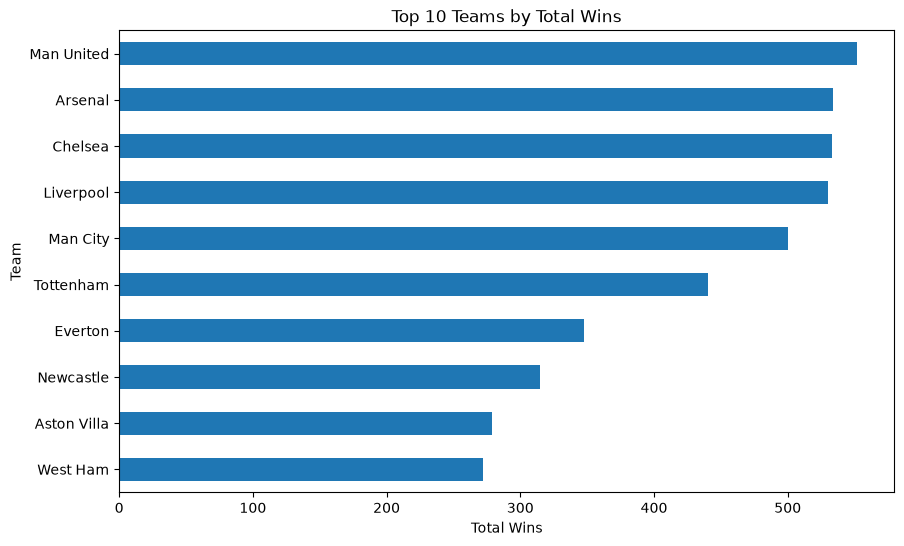

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top10.plot(kind="barh")

plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Total Wins")
plt.ylabel("Team")

plt.gca().invert_yaxis()

plt.show()

# 6: Highest Scoring Teams

In [27]:
home_goals = df.groupby("HomeTeam")["FullTimeHomeGoals"].sum()
away_goals = df.groupby("AwayTeam")["FullTimeAwayGoals"].sum()
total_goals = home_goals.add(away_goals, fill_value=0)

In [28]:
top_goal_teams = total_goals.sort_values(ascending=False)
top_goal_teams.head(10)

HomeTeam
Arsenal        1778
Liverpool      1747
Man City       1719
Man United     1704
Chelsea        1701
Tottenham      1521
Everton        1202
Newcastle      1152
West Ham       1050
Aston Villa    1038
dtype: int64

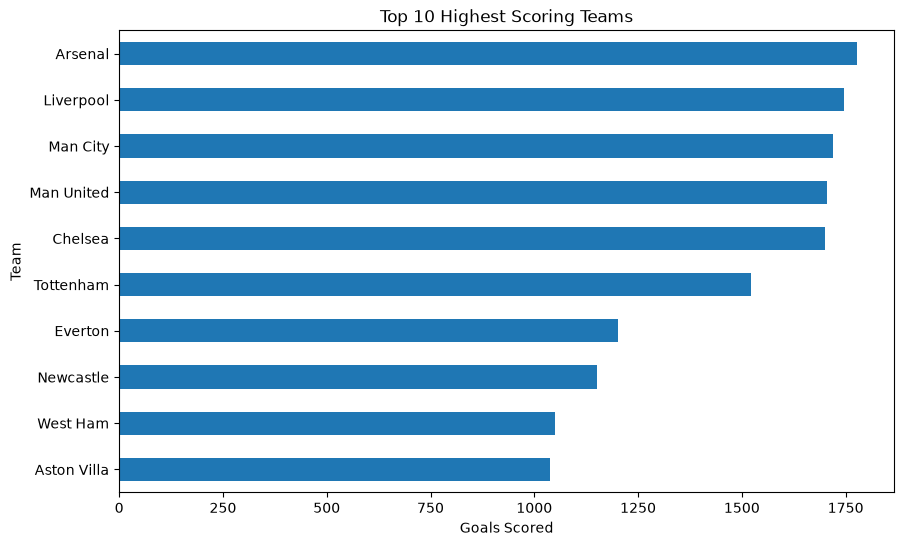

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_goal_teams.head(10).plot(kind="barh")

plt.title("Top 10 Highest Scoring Teams")
plt.xlabel("Goals Scored")
plt.ylabel("Team")

plt.gca().invert_yaxis()

plt.show()

### Observation

- Manchester United, Arsenal, Liverpool and Chelsea are among the highest-scoring teams.
- These clubs have consistently played in the Premier League and maintained strong attacking performances.
- Historical goal-scoring ability may be useful for creating attacking-strength features.

# 7: Best Defensive Teams

In [30]:
home_conceded = df.groupby("HomeTeam")["FullTimeAwayGoals"].sum()
away_conceded = df.groupby("AwayTeam")["FullTimeHomeGoals"].sum()
goals_conceded = home_conceded.add(away_conceded, fill_value=0)

In [31]:
best_defence = goals_conceded.sort_values()
best_defence.head(10)

HomeTeam
Coventry          63
Bradford          70
Blackpool         78
Luton             85
Huddersfield     134
Cardiff          143
Nott'm Forest    177
Ipswich          182
Reading          186
QPR              199
dtype: int64

it is giving wrong approach coz some teams have played the only 1-2 seasons only

now using better EDA technque for this

In [33]:
home_matches = df["HomeTeam"].value_counts()
away_matches = df["AwayTeam"].value_counts()

matches_played = home_matches.add(away_matches, fill_value=0)

In [34]:
home_conceded = df.groupby("HomeTeam")["FullTimeAwayGoals"].sum()
away_conceded = df.groupby("AwayTeam")["FullTimeHomeGoals"].sum()

goals_conceded = home_conceded.add(away_conceded, fill_value=0)

In [35]:
avg_conceded = goals_conceded / matches_played

In [36]:
best_defence = avg_conceded.sort_values()

best_defence.head(10)

HomeTeam
Chelsea          0.962647
Liverpool        0.979744
Man United       0.987207
Arsenal          1.038420
Man City         1.050000
Tottenham        1.260128
Everton          1.268657
Middlesbrough    1.330645
Birmingham       1.352713
Stoke            1.381579
dtype: float64

# Attack vs Defence Analysis

In [37]:
home_goals = df.groupby("HomeTeam")["FullTimeHomeGoals"].sum()
away_goals = df.groupby("AwayTeam")["FullTimeAwayGoals"].sum()

matches_played = (
    df["HomeTeam"].value_counts() +
    df["AwayTeam"].value_counts()
)

avg_goals_scored = (home_goals + away_goals) / matches_played

In [38]:
home_conceded = df.groupby("HomeTeam")["FullTimeAwayGoals"].sum()
away_conceded = df.groupby("AwayTeam")["FullTimeHomeGoals"].sum()

avg_goals_conceded = (
    home_conceded + away_conceded
) / matches_played

In [39]:
team_stats = pd.DataFrame({
    "Avg Goals Scored": avg_goals_scored,
    "Avg Goals Conceded": avg_goals_conceded
})

team_stats.head()

,Avg Goals Scored,Avg Goals Conceded
HomeTeam,,
Arsenal,1.897545,1.038420
Aston Villa,1.258182,1.391515
Birmingham,1.023256,1.352713
Blackburn,1.245098,1.411765
Blackpool,1.447368,2.052632


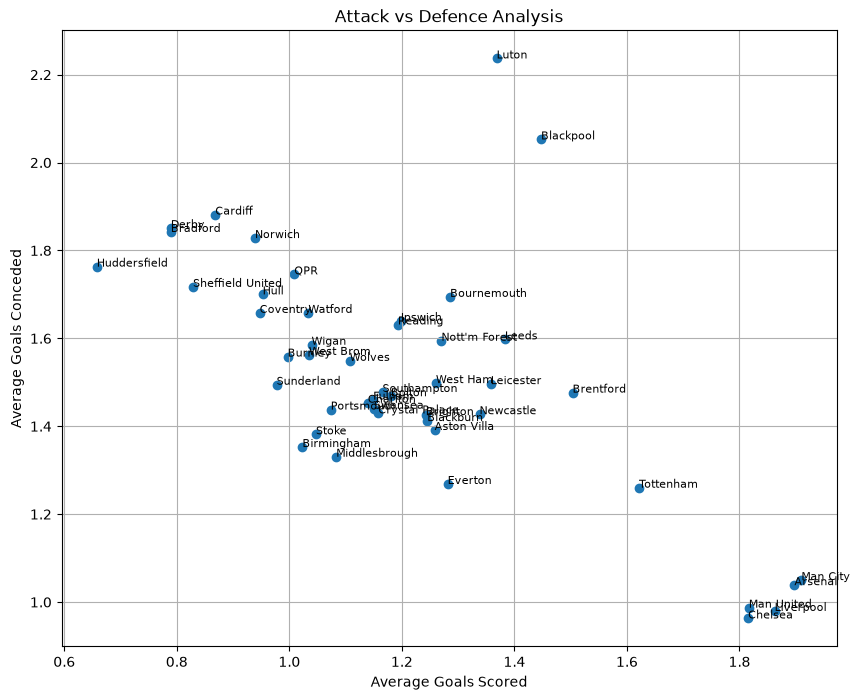

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    team_stats["Avg Goals Scored"],
    team_stats["Avg Goals Conceded"]
)

for team in team_stats.index:
    plt.text(
        team_stats.loc[team, "Avg Goals Scored"],
        team_stats.loc[team, "Avg Goals Conceded"],
        team,
        fontsize=8
    )

plt.xlabel("Average Goals Scored")
plt.ylabel("Average Goals Conceded")
plt.title("Attack vs Defence Analysis")

plt.grid(True)

plt.show()

In [41]:
season_goals = (
    df.groupby("Season")["TotalGoals"]
      .mean()
)

In [42]:
numeric_df = df.select_dtypes(include="number")